---
title: "Fixed orthogonal & PCA warm starts"
short_title: "02 · Fixed & warm-start"
subtitle: "Freezing a PCA frame as a non-trainable rotation, and warm-starting a trainable Householder stack from a target Q"
description: >
  Notebook 01 learned the rotation. Sometimes you would rather fix it from the
  data — a PCA frame — and learn only the marginals, or start a trainable stack
  at that frame and fine-tune. This notebook builds gauss_flows FixedRotation
  from data (the decorrelating PCA rotation, held off the optimiser so it cannot
  drift off the orthogonal manifold), shows why freezing matters, then derives
  the Householder decomposition that warm-starts a trainable HouseholderRotation
  exactly at a target Q.
---

(sec-nb-rot-02)=
# 02 — Fixed orthogonal & PCA warm starts

[Notebook 01](01_householder_orthogonal.ipynb) made the rotation **trainable**.
But often the best rotation is one you do **not** train. The eigenvectors of the
data covariance — the **PCA frame** — decorrelate the data in a single shot
(notebook 00), so a sensible flow can *freeze* that frame and spend its
parameters on the marginals instead. And when you *do* want a trainable rotation,
you rarely want to start from scratch: initialising it at the PCA frame is a
**warm start** that begins where the data already points.

This notebook covers both, with `gauss_flows`:

- **`gf.FixedRotation.from_data`** — the decorrelating PCA rotation, held
  *non-trainable* so the optimiser cannot nudge it off the orthogonal manifold.
- **Why freezing matters** — an unconstrained matrix trained by Adam drifts off
  $O(d)$, silently corrupting the flow's log-det accounting.
- **Warm-starting** a trainable `gf.HouseholderRotation` at a target $Q$ via a
  closed-form Householder decomposition — reproducing the PCA frame *exactly* at
  initialisation, then fine-tuning from there.

**What you will see**

- `from_data` builds a pure rotation (orthogonal, log-det $0$) whose rows are the
  principal axes, and it decorrelates the data.
- A free matrix trained on a decorrelation proxy leaves $O(d)$ — the failure
  `FixedRotation`'s `NonTrainable` wrapper exists to prevent.
- A Householder stack initialised from the decomposition matches the PCA frame to
  machine precision and then trains away from it freely.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax

import gauss_flows as gf
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(0)

## 1. The PCA frame as a fixed rotation

`gf.FixedRotation.from_data(X)` computes the eigenvectors of $\mathrm{Cov}(X)$
and stores the orthogonal matrix $Q$ whose **rows are the principal axes**, in
descending-eigenvalue order. The map $y = Qx$ is the **decorrelating PCA
projection** — a *pure* rotation, so $|\det Q| = 1$ and its log-det is exactly
$0$ (no whitening / rescale; that is left to the marginal step, cf.
[notebook 00 §2](00_rotation_zoo.ipynb)). We fit it to a correlated cloud and
check it both rotates and decorrelates.

orthogonal? ||Q^T Q - I|| = 8.9e-16
log_det = +0.0e+00   round-trip = 1.1e-15
max |off-diagonal| covariance:  before = 0.753   after = 1.16e-15


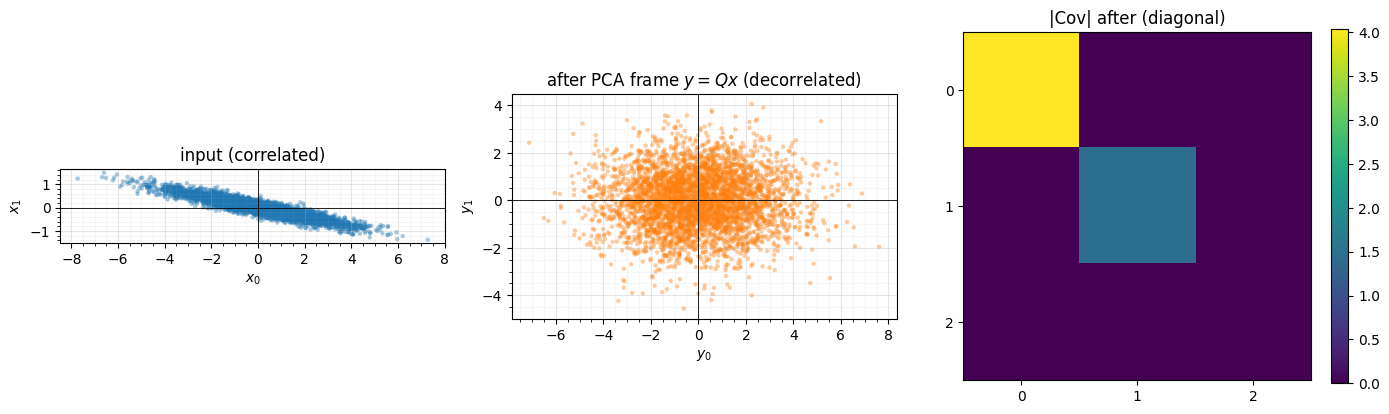

In [2]:
d = 3
n = 4000
M = jr.normal(jr.key(0), (d, d))
X = jr.normal(jr.key(1), (n, d)) @ M.T          # correlated, anisotropic

rot = gf.FixedRotation.from_data(X)
Q = np.asarray(rot.matrix)
Y = jax.vmap(rot.transform)(X)

x0 = jr.normal(jr.key(2), (d,))
z0, ld = rot.transform_and_log_det(x0)
xi, _ = rot.inverse_and_log_det(z0)
print(f"orthogonal? ||Q^T Q - I|| = {np.abs(Q.T @ Q - np.eye(d)).max():.1e}")
print(f"log_det = {float(ld):+.1e}   round-trip = {float(jnp.abs(x0 - xi).max()):.1e}")

cov_in = np.cov(np.asarray(X).T)
cov_out = np.cov(np.asarray(Y).T)
print(f"max |off-diagonal| covariance:  before = {np.abs(cov_in - np.diag(np.diag(cov_in))).max():.3f}"
      f"   after = {np.abs(cov_out - np.diag(np.diag(cov_out))).max():.2e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
axes[0].scatter(X[:, 0], X[:, 1], color="tab:blue", **SCATTER_KW)
axes[0].set(title="input (correlated)", xlabel="$x_0$", ylabel="$x_1$")
axes[1].scatter(Y[:, 0], Y[:, 1], color="tab:orange", **SCATTER_KW)
axes[1].set(title="after PCA frame $y=Qx$ (decorrelated)", xlabel="$y_0$", ylabel="$y_1$")
for ax in axes[:2]:
    ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
    ax.set_aspect("equal"); style_ax(ax)
im = axes[2].imshow(np.abs(cov_out), cmap="viridis")
axes[2].set(title="|Cov| after (diagonal)", xticks=range(d), yticks=range(d))
fig.colorbar(im, ax=axes[2], fraction=0.046)
fig.tight_layout()

The frame rotates the cloud onto its principal axes and the output covariance is
diagonal (off-diagonals drop from $\sim$O(1) to $\sim10^{-15}$). Note it does
**not** rescale — the axis variances are the eigenvalues, still unequal — which
is exactly the point: the rotation decorrelates, the *marginal* step that
follows it standardises. log-det stays $0$.

## 2. Why freeze it

A PCA frame is fit once and should stay put. `FixedRotation` stores its matrix
wrapped in `paramax.NonTrainable`, so `flowjax`'s `fit_to_data` **skips it**
during gradient descent. That is not a cosmetic choice. If you instead expose the
rotation as a raw, unconstrained matrix and let Adam touch it, it drifts off the
orthogonal manifold — and then $|\det Q|\neq 1$, so a flow that *assumes*
rotations contribute log-det $0$ will silently mis-account the likelihood. We
demonstrate the drift on a decorrelation proxy.

unconstrained matrix after 400 steps:
  ||W^T W - I|| = 0.221   (left the orthogonal manifold)
  log|det W|    = -0.158   (a flow would wrongly book this as 0)


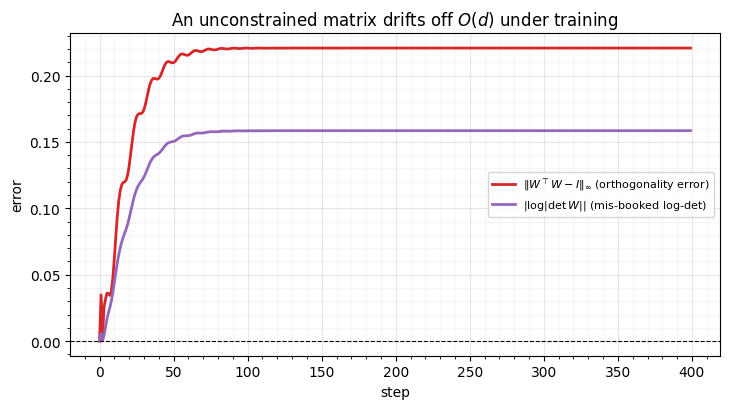

In [3]:
Xc = X - X.mean(0)

def offdiag_loss_matrix(W):
    """Sum of squared off-diagonal covariance of W x — a decorrelation proxy."""
    C = (Xc @ W.T).T @ (Xc @ W.T) / n
    return jnp.sum((C - jnp.diag(jnp.diag(C))) ** 2)

W = jnp.asarray(Q)                                   # start at the (orthogonal) PCA frame
opt = optax.adam(2e-2)
state = opt.init(W)

@jax.jit
def step(W, state):
    loss, g = jax.value_and_grad(offdiag_loss_matrix)(W)
    upd, state = opt.update(g, state)
    return optax.apply_updates(W, upd), state, loss

ortho_err, logdets = [], []
for _ in range(400):
    W, state, _ = step(W, state)
    ortho_err.append(float(jnp.abs(W.T @ W - jnp.eye(d)).max()))
    logdets.append(float(jnp.linalg.slogdet(W)[1]))

print(f"unconstrained matrix after 400 steps:")
print(f"  ||W^T W - I|| = {ortho_err[-1]:.3f}   (left the orthogonal manifold)")
print(f"  log|det W|    = {logdets[-1]:+.3f}   (a flow would wrongly book this as 0)")

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(ortho_err, color="tab:red", lw=2, label=r"$\|W^\top W - I\|_\infty$ (orthogonality error)")
ax.plot(np.abs(logdets), color="tab:purple", lw=2, label=r"$|\log|\det W||$ (mis-booked log-det)")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set(title="An unconstrained matrix drifts off $O(d)$ under training",
       xlabel="step", ylabel="error")
ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

Starting *exactly* at the orthogonal PCA frame, the free matrix walks away from
$O(d)$ within a few hundred steps — it "solves" the decorrelation proxy by
quietly rescaling, and now its true log-det is $\neq 0$. `FixedRotation` avoids
this by freezing the frame; `HouseholderRotation`/`OrthogonalRotation` (notebook
01) avoid it by *parameterising* orthogonality so every step stays on the
manifold. The lesson: **never** train a rotation as a raw matrix. Either freeze
it, or parameterise it.

This is the "fix the frame, learn the marginals" pattern: drop a
`FixedRotation.from_data` between marginal blocks and the rotation does its
decorrelating job for free while the trainable marginals do the standardising.

## 3. Warm-starting a trainable stack from a target $Q$

What if we want the rotation trainable *and* want it to start at the PCA frame?
We need to set a `HouseholderRotation`'s reflection vectors so that its product
equals a given $Q$. That is a closed-form linear-algebra problem — the
**Householder decomposition** behind QR: zero out $Q$ column by column with
reflections, then absorb the residual $\pm 1$ diagonal as axis reflections. The
reflectors $\{u_k\}$ satisfy $H(u_1)\cdots H(u_m) = Q$.

In [4]:
def decompose_to_reflectors(Q):
    """Reflection vectors P such that gauss_flows' product H(P[-1])...H(P[0]) = Q.

    Column-by-column Householder zeroing reduces Q to a sign diagonal; each
    remaining -1 is one more axis reflection. Returns P ordered for gf's
    convention (gf applies reflections in array order, composing right-to-left).
    """
    Q = np.asarray(Q, float)
    d = Q.shape[0]
    R = Q.copy()
    us = []
    for k in range(d - 1):
        x = R[k:, k].copy()
        e = np.zeros_like(x); e[0] = 1.0
        alpha = -np.sign(x[0] or 1.0) * np.linalg.norm(x)   # stable sign choice
        v = x - alpha * e
        v = v / np.linalg.norm(v)
        u = np.zeros(d); u[k:] = v
        us.append(u)
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])       # R <- H(v) R
    for j in np.where(np.sign(np.diag(R)) < 0)[0]:          # absorb the sign diagonal
        ej = np.zeros(d); ej[j] = 1.0
        us.append(ej)
    # H(us[-1])...H(us[0]) Q = I  =>  Q = H(us[0])...H(us[-1]); gf wants reversed order
    return np.array(us[::-1])

P = decompose_to_reflectors(Q)
warm = eqx.tree_at(lambda m: m.params,
                   gf.HouseholderRotation(n_reflections=P.shape[0], shape=(d,)),
                   jnp.asarray(P))
Q_warm = jax.vmap(warm.transform)(jnp.eye(d)).T
print(f"decomposed PCA frame into {P.shape[0]} reflections")
print(f"warm-started HouseholderRotation reproduces Q? ||Q - Q_warm|| = "
      f"{float(jnp.abs(jnp.asarray(Q) - Q_warm).max()):.1e}")
print(f"matches FixedRotation output on data? max|Δ| = "
      f"{float(jnp.abs(jax.vmap(warm.transform)(X) - Y).max()):.1e}")

decomposed PCA frame into 4 reflections
warm-started HouseholderRotation reproduces Q? ||Q - Q_warm|| = 4.4e-16
matches FixedRotation output on data? max|Δ| = 4.4e-15


The trainable stack now *starts* at the PCA frame to machine precision — it is
numerically identical to the `FixedRotation`, but its reflection vectors are
free to move. We contrast a **cold start** (random reflectors) against this
**warm start** while training the same decorrelation objective (now safely,
because the stack stays orthogonal at every step).

cold start: off-diag loss 6.26e+00 -> 3.83e-19
warm start: off-diag loss 3.17e-30 -> 3.58e-19  (begins at the answer)


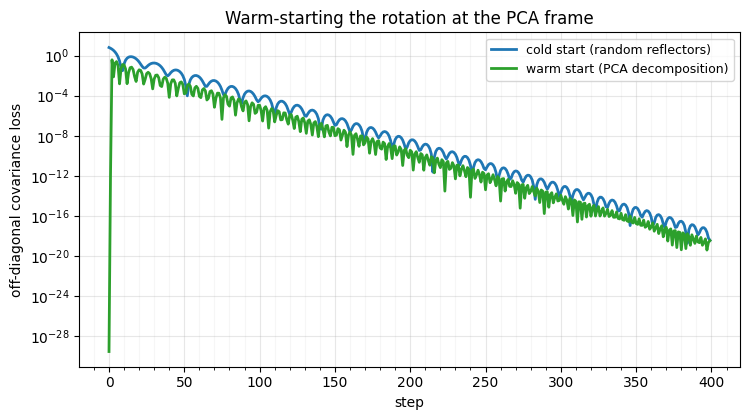

In [5]:
def offdiag_loss_layer(layer):
    Yl = jax.vmap(layer.transform)(Xc)
    C = Yl.T @ Yl / n
    return jnp.sum((C - jnp.diag(jnp.diag(C))) ** 2)

def train_layer(layer, steps=400, lr=2e-2):
    params, static = eqx.partition(layer, eqx.is_inexact_array)
    opt = optax.adam(lr); state = opt.init(params)

    @eqx.filter_jit
    def step(params, state):
        loss, g = eqx.filter_value_and_grad(
            lambda p: offdiag_loss_layer(eqx.combine(p, static)))(params)
        upd, state = opt.update(g, state)
        return eqx.apply_updates(params, upd), state, loss

    hist = []
    for _ in range(steps):
        params, state, loss = step(params, state)
        hist.append(float(loss))
    return hist

cold_hist = train_layer(gf.HouseholderRotation(n_reflections=d, shape=(d,)))
warm_hist = train_layer(warm)
print(f"cold start: off-diag loss {cold_hist[0]:.2e} -> {cold_hist[-1]:.2e}")
print(f"warm start: off-diag loss {warm_hist[0]:.2e} -> {warm_hist[-1]:.2e}  (begins at the answer)")

fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.semilogy(np.maximum(cold_hist, 1e-32), color="tab:blue", lw=2, label="cold start (random reflectors)")
ax.semilogy(np.maximum(warm_hist, 1e-32), color="tab:green", lw=2, label="warm start (PCA decomposition)")
ax.set(title="Warm-starting the rotation at the PCA frame",
       xlabel="step", ylabel="off-diagonal covariance loss")
ax.legend(fontsize=9); style_ax(ax)
fig.tight_layout()

The warm-started stack begins already decorrelated (loss $\sim10^{-30}$) — it
inherited the PCA solution — while the cold start has to descend from $\sim6$.
Both reach machine zero, confirming the trainable stack *can* learn the frame;
the warm start just gets it for free and then fine-tunes from a sensible place.
This is the bridge between [notebook 01](01_householder_orthogonal.ipynb)'s
trainable rotation and this notebook's fixed one: **decompose → initialise →
fine-tune**, the same recipe RBIG uses to warm-start parametric flows (Part 3).

## Recap

| tool | rotation is | log-det | use when |
|---|---|---|---|
| `gf.FixedRotation.from_data` | frozen PCA frame (`NonTrainable`) | $0$ | fix the frame, learn only marginals |
| raw trainable matrix | **drifts off $O(d)$** | wrong | ✗ never — log-det silently corrupts |
| `gf.HouseholderRotation` (warm-started) | trainable, init at $Q$ | $0$ | start at PCA, fine-tune by NLL |

The Householder decomposition turns any target $Q$ — a PCA frame, a previous
layer's rotation — into an exact initialisation for a trainable stack.

**Next up.** Rotations are the dense orthogonal mixers. Image and high-dimensional
flows need *cheap structured* linear layers with tractable log-dets:
[03 — Structured linear layers](03_conv1x1_actnorm.ipynb) covers the invertible
$1\times1$ convolution (LU-parameterised, $\log|\det| = \sum\log|s|$) and
**ActNorm**, the data-dependent affine that makes deep stacks trainable.